# Ounass A/B Test Analysis — Curated For You Carousel
**Growth Case Study Q7**

Comparing two recommendation algorithms via A/B test on the homepage 'Curated For You' carousel.

### Test Setup
- **Control**: Existing recommendation algorithm
- **Test**: New personalised recommendation algorithm
- **Period**: December 1–10, 2024 (10 days)
- **Users**: ~165K unique users split across variants
- **Data**: Event-level with binary flags for plp_view, plp_click, purchase

### Analysis Plan
1. Sample Ratio Mismatch (SRM) check — validate randomisation
2. Aggregate to user level — correct unit of analysis
3. Primary metric: Purchase rate (purchases / users)
4. Secondary metrics: PLP click rate, PLP view rate
5. Statistical testing: two-proportion z-test at 95% confidence
6. Segment analysis: by country, language, login status, product class
7. Daily trend analysis
8. Business recommendation

---
## 1. Setup & Load Data

In [2]:
# Install dependencies if needed
%pip install matplotlib scipy numpy pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 41.3 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 40.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [matplotlib]5 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams.update({
    'figure.facecolor': '#F5F7FA',
    'axes.facecolor': '#FFFFFF',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

NAVY  = '#0D1F3C'
GOLD  = '#C9A84C'
GREEN = '#0D9488'
RED   = '#E05252'
BLUE  = '#3B82F6'
PURPLE= '#8B5CF6'

print('Imports successful.')

Imports successful.


In [4]:
df = pd.read_parquet('ab_model_data.parquet')

print(f'Loaded: {len(df):,} events')
print(f'Users:  {df["user_identifier"].nunique():,}')
print(f'Period: {df["dt"].min()} to {df["dt"].max()}')
print(f'\nVariant distribution:')
print(df['variant'].value_counts())
df.head(3)

Loaded: 14,078,419 events
Users:  165,694
Period: 2024-12-01 to 2024-12-10

Variant distribution:
variant
test       7430572
control    6647847
Name: count, dtype: int64


,dt,variant,country,ga_language,productclass,is_logged_in,user_identifier,plp_view,plp_click,purchase
0,2024-12-06,control,SA,Arabic,Bags,logged out,85f310bea532e4273dc682942f9ecdef41b12a844b8c6a...,1,0,0
1,2024-12-06,control,SA,Arabic,Clothing,logged out,9b729369e5c04f2dc1f27e2336e0f658b1bb7a55bb9e73...,1,0,0
2,2024-12-06,test,SA,Arabic,Accessories,logged out,eededf925f895050055e841494ace59ec2ad3f8ea8e7fd...,1,0,0


---
## 2. Sample Ratio Mismatch (SRM) Check
Before any analysis, verify that users were split roughly 50/50 between variants.
SRM indicates a broken randomisation — if detected, results cannot be trusted.

**Test**: Chi-squared goodness-of-fit against expected 50/50 split at user level.

In [6]:
# Aggregate to user level first — one row per user
user_df = (
    df.groupby(['user_identifier', 'variant'])
    .agg(
        plp_views   = ('plp_view',  'sum'),
        plp_clicks  = ('plp_click', 'sum'),
        purchases   = ('purchase',  'sum'),
        events      = ('plp_view',  'count'),
        country     = ('country',   'first'),
        language    = ('ga_language','first'),
        is_logged_in= ('is_logged_in','first'),
    )
    .reset_index()
)

# Binary flags at user level
user_df['did_view']     = (user_df['plp_views']  > 0).astype(int)
user_df['did_click']    = (user_df['plp_clicks'] > 0).astype(int)
user_df['did_purchase'] = (user_df['purchases']  > 0).astype(int)

n_control = (user_df['variant'] == 'control').sum()
n_test    = (user_df['variant'] == 'test').sum()
n_total   = n_control + n_test

print(f'User-level dataset: {n_total:,} users')
print(f'  Control: {n_control:,} ({n_control/n_total:.1%})')
print(f'  Test:    {n_test:,} ({n_test/n_total:.1%})')

# SRM Chi-squared test
observed  = np.array([n_control, n_test])
expected  = np.array([n_total / 2, n_total / 2])
chi2, srm_p = stats.chisquare(observed, expected)

print(f'\n── SRM Check ──')
print(f'  Chi-squared: {chi2:.4f}')
print(f'  p-value:     {srm_p:.6f}')

if srm_p < 0.01:
    print(f'     SRM DETECTED — split is {n_control/n_total:.1%} / {n_test/n_total:.1%}, expected 50/50')
    print(f'     Possible causes: bot traffic, logging issues, sticky assignment failure')
    print(f'     Action: flag to engineering, analyse with caution')
else:
    print(f'     No SRM detected — randomisation looks clean')

User-level dataset: 165,694 users
  Control: 82,106 (49.6%)
  Test:    83,588 (50.4%)

── SRM Check ──
  Chi-squared: 13.2553
  p-value:     0.000272
     SRM DETECTED — split is 49.6% / 50.4%, expected 50/50
     Possible causes: bot traffic, logging issues, sticky assignment failure
     Action: flag to engineering, analyse with caution


---
## 3. Primary Metric — Purchase Rate
**Definition**: % of users who made at least one purchase during the test period.

This is the primary metric because it directly captures revenue impact. PLP click rate alone could be gamed by showing clickbait recommendations — purchase rate validates real intent.

In [7]:
def z_test_proportions(n_control, n_test, conv_control, conv_test, metric_name='Metric', alpha=0.05):
    """
    Two-proportion z-test for A/B test analysis.
    Returns detailed results dict.
    """
    p_control = conv_control / n_control
    p_test    = conv_test    / n_test
    p_pooled  = (conv_control + conv_test) / (n_control + n_test)
    
    se = np.sqrt(p_pooled * (1 - p_pooled) * (1/n_control + 1/n_test))
    z  = (p_test - p_control) / se
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))  # two-tailed
    
    # 95% confidence interval on the difference
    se_diff = np.sqrt(
        p_control * (1 - p_control) / n_control +
        p_test    * (1 - p_test)    / n_test
    )
    z_crit  = stats.norm.ppf(1 - alpha/2)
    ci_low  = (p_test - p_control) - z_crit * se_diff
    ci_high = (p_test - p_control) + z_crit * se_diff
    
    relative_lift = (p_test - p_control) / p_control * 100
    significant   = p_value < alpha
    
    result = {
        'metric':        metric_name,
        'n_control':     n_control,
        'n_test':        n_test,
        'rate_control':  p_control,
        'rate_test':     p_test,
        'absolute_lift': p_test - p_control,
        'relative_lift': relative_lift,
        'z_stat':        z,
        'p_value':       p_value,
        'ci_low':        ci_low,
        'ci_high':       ci_high,
        'significant':   significant,
    }
    
    sig_str = '✅ SIGNIFICANT' if significant else '❌ NOT SIGNIFICANT'
    print(f'\n── {metric_name} ──')
    print(f'  Control:      {p_control:.4%}  ({conv_control:,} / {n_control:,})')
    print(f'  Test:         {p_test:.4%}  ({conv_test:,} / {n_test:,})')
    print(f'  Relative lift: {relative_lift:+.2f}%')
    print(f'  Absolute lift: {(p_test-p_control):.4%}')
    print(f'  95% CI:       [{ci_low:.4%}, {ci_high:.4%}]')
    print(f'  z-stat:       {z:.4f}')
    print(f'  p-value:      {p_value:.6f}')
    print(f'  Result:       {sig_str} (alpha={alpha})')
    
    return result

# Aggregate by variant
grp = user_df.groupby('variant').agg(
    n_users      = ('user_identifier', 'count'),
    purchasers   = ('did_purchase',    'sum'),
    clickers     = ('did_click',       'sum'),
    viewers      = ('did_view',        'sum'),
).reset_index()

ctrl = grp[grp['variant'] == 'control'].iloc[0]
test = grp[grp['variant'] == 'test'].iloc[0]

print('='*55)
print(' PRIMARY METRIC ANALYSIS')
print('='*55)

purchase_result = z_test_proportions(
    ctrl['n_users'], test['n_users'],
    ctrl['purchasers'], test['purchasers'],
    metric_name='Purchase Rate'
)

 PRIMARY METRIC ANALYSIS

── Purchase Rate ──
  Control:      7.3186%  (6,009 / 82,106)
  Test:         8.4821%  (7,090 / 83,588)
  Relative lift: +15.90%
  Absolute lift: 1.1635%
  95% CI:       [0.9039%, 1.4231%]
  z-stat:       8.7758
  p-value:      0.000000
  Result:       ✅ SIGNIFICANT (alpha=0.05)


---
## 4. Secondary Metrics — PLP Click Rate & View Rate

In [8]:
print('='*55)
print(' SECONDARY METRICS')
print('='*55)

click_result = z_test_proportions(
    ctrl['n_users'], test['n_users'],
    ctrl['clickers'], test['clickers'],
    metric_name='PLP Click Rate'
)

view_result = z_test_proportions(
    ctrl['n_users'], test['n_users'],
    ctrl['viewers'], test['viewers'],
    metric_name='PLP View Rate'
)

# Summary table
results = [purchase_result, click_result, view_result]
summary = pd.DataFrame([{
    'Metric':        r['metric'],
    'Control Rate':  f"{r['rate_control']:.3%}",
    'Test Rate':     f"{r['rate_test']:.3%}",
    'Relative Lift': f"{r['relative_lift']:+.2f}%",
    'p-value':       f"{r['p_value']:.4f}",
    'Significant':   '✅ Yes' if r['significant'] else '❌ No',
} for r in results])

print('\n── Summary Table ──')
display(summary)

 SECONDARY METRICS

── PLP Click Rate ──
  Control:      38.6427%  (31,728 / 82,106)
  Test:         41.2404%  (34,472 / 83,588)
  Relative lift: +6.72%
  Absolute lift: 2.5976%
  95% CI:       [2.1262%, 3.0691%]
  z-stat:       10.7935
  p-value:      0.000000
  Result:       ✅ SIGNIFICANT (alpha=0.05)

── PLP View Rate ──
  Control:      98.7882%  (81,111 / 82,106)
  Test:         98.8563%  (82,632 / 83,588)
  Relative lift: +0.07%
  Absolute lift: 0.0681%
  95% CI:       [-0.0358%, 0.1721%]
  z-stat:       1.2857
  p-value:      0.198562
  Result:       ❌ NOT SIGNIFICANT (alpha=0.05)

── Summary Table ──


,Metric,Control Rate,Test Rate,Relative Lift,p-value,Significant
0,Purchase Rate,7.319%,8.482%,+15.90%,0.0000,✅ Yes
1,PLP Click Rate,38.643%,41.240%,+6.72%,0.0000,✅ Yes
2,PLP View Rate,98.788%,98.856%,+0.07%,0.1986,❌ No


---
## 5. Visualisation — Metric Comparison

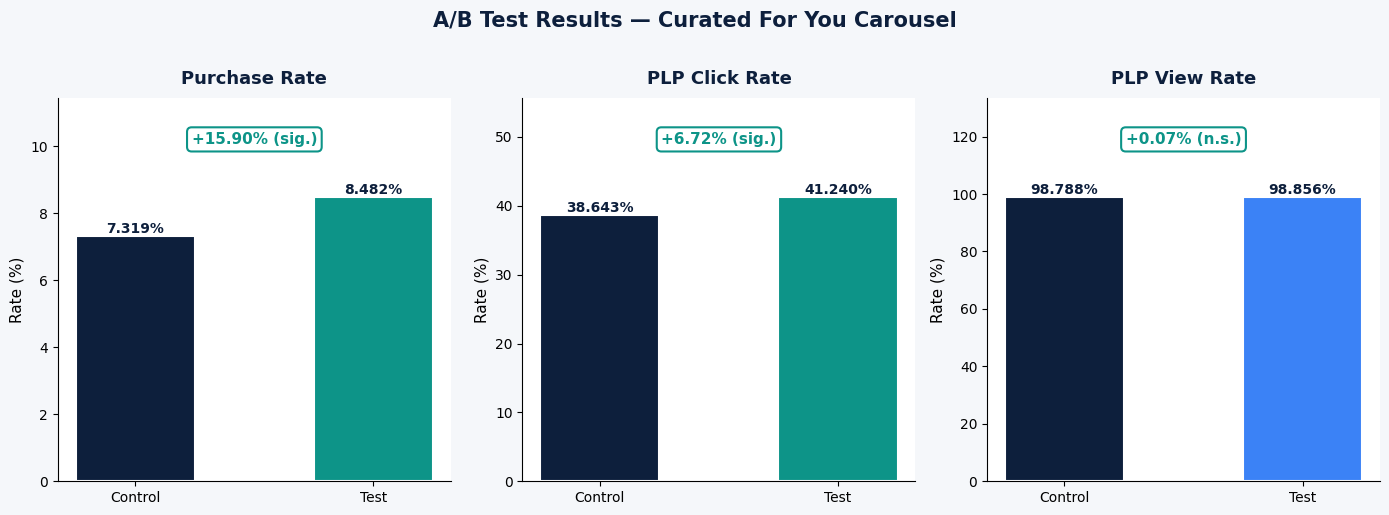

Saved: ab_metrics_comparison.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('A/B Test Results — Curated For You Carousel', 
             fontsize=15, fontweight='bold', color=NAVY, y=1.02)

metrics_plot = [
    ('Purchase Rate',  purchase_result),
    ('PLP Click Rate', click_result),
    ('PLP View Rate',  view_result),
]

for ax, (title, r) in zip(axes, metrics_plot):
    bars = ax.bar(
        ['Control', 'Test'],
        [r['rate_control'] * 100, r['rate_test'] * 100],
        color=[NAVY, GREEN if r['significant'] else BLUE],
        width=0.5, edgecolor='white', linewidth=1.5
    )
    
    # Value labels on bars
    for bar, val in zip(bars, [r['rate_control'], r['rate_test']]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.3%}', ha='center', va='bottom', 
                fontsize=10, fontweight='bold', color=NAVY)
    
    # Lift annotation
    lift_color = GREEN if r['relative_lift'] > 0 else RED
    sig_label  = '(sig.)' if r['significant'] else '(n.s.)'
    ax.text(0.5, 0.88, f"{r['relative_lift']:+.2f}% {sig_label}",
            transform=ax.transAxes, ha='center', fontsize=11,
            fontweight='bold', color=lift_color,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                      edgecolor=lift_color, linewidth=1.5))
    
    ax.set_title(title, fontweight='bold', color=NAVY, pad=10)
    ax.set_ylabel('Rate (%)')
    ax.set_ylim(0, max(r['rate_control'], r['rate_test']) * 100 * 1.35)
    ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig('ab_metrics_comparison.png', dpi=150, bbox_inches='tight',
            facecolor='#F5F7FA')
plt.show()
print('Saved: ab_metrics_comparison.png')

---
## 6. Confidence Interval Plot

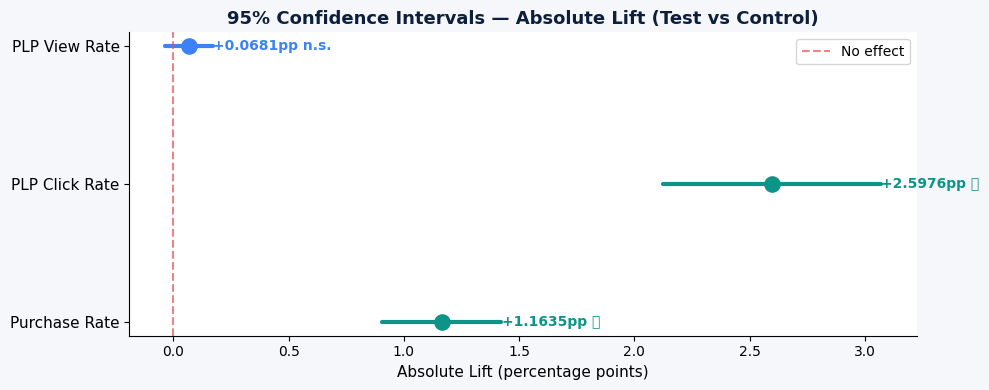

Saved: ab_confidence_intervals.png


In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor('#F5F7FA')

metric_labels = ['Purchase Rate', 'PLP Click Rate', 'PLP View Rate']
lifts    = [r['absolute_lift'] * 100 for r in results]
ci_lows  = [r['ci_low']  * 100 for r in results]
ci_highs = [r['ci_high'] * 100 for r in results]
sigs     = [r['significant'] for r in results]

y_pos = range(len(metric_labels))

for i, (lift, low, high, sig, label) in enumerate(
        zip(lifts, ci_lows, ci_highs, sigs, metric_labels)):
    color = GREEN if sig else BLUE
    ax.plot([low, high], [i, i], color=color, linewidth=3, solid_capstyle='round')
    ax.scatter([lift], [i], color=color, s=120, zorder=5)
    ax.text(high + 0.002, i, f'{lift:+.4f}pp {"✅" if sig else "n.s."}',
            va='center', fontsize=10, color=color, fontweight='bold')

ax.axvline(0, color=RED, linewidth=1.5, linestyle='--', alpha=0.7, label='No effect')
ax.set_yticks(list(y_pos))
ax.set_yticklabels(metric_labels, fontsize=11)
ax.set_xlabel('Absolute Lift (percentage points)', fontsize=11)
ax.set_title('95% Confidence Intervals — Absolute Lift (Test vs Control)',
             fontweight='bold', color=NAVY, fontsize=13)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('ab_confidence_intervals.png', dpi=150, bbox_inches='tight',
            facecolor='#F5F7FA')
plt.show()
print('Saved: ab_confidence_intervals.png')

---
## 7. Segment Analysis
Break down results by key dimensions to understand where the effect is strongest and check for heterogeneity.

In [11]:
def segment_analysis(user_df, segment_col, metric_col='did_purchase', min_users=100):
    results = []
    segments = user_df[segment_col].dropna().unique()
    
    for seg in sorted(segments):
        seg_df = user_df[user_df[segment_col] == seg]
        ctrl_s = seg_df[seg_df['variant'] == 'control']
        test_s = seg_df[seg_df['variant'] == 'test']
        
        if len(ctrl_s) < min_users or len(test_s) < min_users:
            continue
        
        n_c, n_t   = len(ctrl_s), len(test_s)
        conv_c     = ctrl_s[metric_col].sum()
        conv_t     = test_s[metric_col].sum()
        rate_c     = conv_c / n_c
        rate_t     = conv_t / n_t
        
        p_pooled   = (conv_c + conv_t) / (n_c + n_t)
        se         = np.sqrt(p_pooled * (1-p_pooled) * (1/n_c + 1/n_t))
        z          = (rate_t - rate_c) / se if se > 0 else 0
        p_val      = 2 * (1 - stats.norm.cdf(abs(z)))
        rel_lift   = (rate_t - rate_c) / rate_c * 100 if rate_c > 0 else 0
        
        results.append({
            'Segment':       str(seg),
            'N Control':     n_c,
            'N Test':        n_t,
            'Control Rate':  f'{rate_c:.3%}',
            'Test Rate':     f'{rate_t:.3%}',
            'Relative Lift': f'{rel_lift:+.1f}%',
            'p-value':       round(p_val, 4),
            'Sig':           '✅' if p_val < 0.05 else '—',
            '_lift':         rel_lift,
            '_rate_c':       rate_c,
            '_rate_t':       rate_t,
        })
    
    return pd.DataFrame(results)

print('── Purchase Rate by Country ──')
country_seg = segment_analysis(user_df, 'country')
display(country_seg.drop(columns=['_lift','_rate_c','_rate_t']))

print('\n── Purchase Rate by Login Status ──')
login_seg = segment_analysis(user_df, 'is_logged_in')
display(login_seg.drop(columns=['_lift','_rate_c','_rate_t']))

print('\n── Purchase Rate by Language ──')
lang_seg = segment_analysis(user_df, 'language')
display(lang_seg.drop(columns=['_lift','_rate_c','_rate_t']))

── Purchase Rate by Country ──


,Segment,N Control,N Test,Control Rate,Test Rate,Relative Lift,p-value,Sig
0,AE,27215,30154,9.701%,11.312%,+16.6%,0.0000,✅
1,BH,742,693,6.873%,6.205%,-9.7%,0.6091,—
2,KW,7189,6859,7.052%,7.158%,+1.5%,0.8068,—
3,OM,663,620,5.882%,4.839%,-17.7%,0.4076,—
4,Other,296,259,1.689%,1.931%,+14.3%,0.8312,—
5,QA,2026,1814,5.676%,6.064%,+6.8%,0.6095,—
6,SA,43975,43189,6.031%,6.946%,+15.2%,0.0000,✅



── Purchase Rate by Login Status ──


,Segment,N Control,N Test,Control Rate,Test Rate,Relative Lift,p-value,Sig
0,logged in,35399,52356,10.836%,10.698%,-1.3%,0.5157,—
1,logged out,46707,31232,4.652%,4.768%,+2.5%,0.4566,—



── Purchase Rate by Language ──


,Segment,N Control,N Test,Control Rate,Test Rate,Relative Lift,p-value,Sig
0,Arabic,43234,40920,6.072%,6.811%,+12.2%,0.0,✅
1,English,38872,42668,8.705%,10.085%,+15.8%,0.0,✅


In [12]:
print('── Purchase Rate by Product Class ──')
# Product class is at event level — assign most frequent per user
user_productclass = (
    df.groupby('user_identifier')['productclass']
    .agg(lambda x: x.dropna().mode()[0] if len(x.dropna()) > 0 else np.nan)
    .reset_index()
    .rename(columns={'productclass': 'top_productclass'})
)
user_df2 = user_df.merge(user_productclass, on='user_identifier', how='left')
pc_seg = segment_analysis(user_df2, 'top_productclass')
display(pc_seg.drop(columns=['_lift','_rate_c','_rate_t']))

── Purchase Rate by Product Class ──


,Segment,N Control,N Test,Control Rate,Test Rate,Relative Lift,p-value,Sig
0,Accessories,7485,7606,5.705%,6.232%,+9.2%,0.1718,—
1,Bags,9898,9955,4.395%,5.264%,+19.8%,0.0043,✅
2,Beauty,11463,11831,9.666%,10.980%,+13.6%,0.0010,✅
3,Clothing,40558,41226,8.220%,9.720%,+18.2%,0.0000,✅
4,Home,268,294,3.731%,5.102%,+36.7%,0.4312,—
5,Jewellery,2388,2366,4.523%,4.861%,+7.5%,0.5817,—
6,Shoes,10032,10300,5.851%,6.369%,+8.8%,0.1235,—


---
## 8. Segment Visualisation

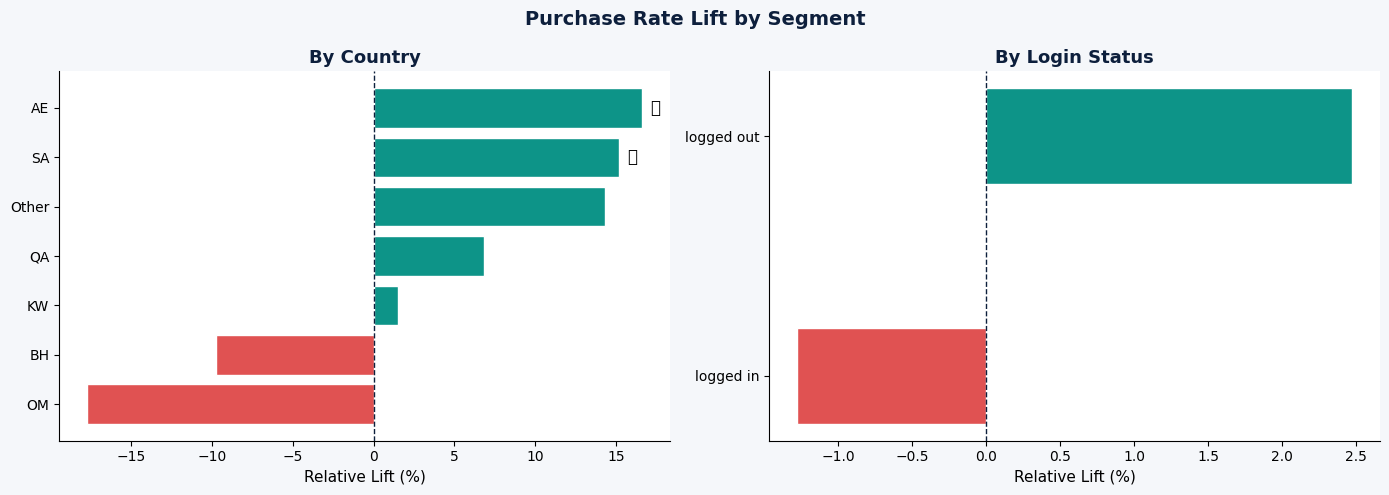

Saved: ab_segment_analysis.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Purchase Rate Lift by Segment', fontsize=14,
             fontweight='bold', color=NAVY)

# Country segment
ax = axes[0]
cs = country_seg.sort_values('_lift', ascending=True)
colors_c = [GREEN if l > 0 else RED for l in cs['_lift']]
bars = ax.barh(cs['Segment'], cs['_lift'], color=colors_c,
               edgecolor='white', linewidth=1)
ax.axvline(0, color=NAVY, linewidth=1, linestyle='--')
for bar, p in zip(bars, cs['p-value']):
    sig = '✅' if p < 0.05 else ''
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            sig, va='center', fontsize=12)
ax.set_xlabel('Relative Lift (%)', fontsize=11)
ax.set_title('By Country', fontweight='bold', color=NAVY)

# Login status
ax = axes[1]
ls = login_seg.sort_values('_lift', ascending=True)
colors_l = [GREEN if l > 0 else RED for l in ls['_lift']]
bars = ax.barh(ls['Segment'], ls['_lift'], color=colors_l,
               edgecolor='white', linewidth=1, height=0.4)
ax.axvline(0, color=NAVY, linewidth=1, linestyle='--')
for bar, p in zip(bars, ls['p-value']):
    sig = '✅' if p < 0.05 else ''
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            sig, va='center', fontsize=12)
ax.set_xlabel('Relative Lift (%)', fontsize=11)
ax.set_title('By Login Status', fontweight='bold', color=NAVY)

plt.tight_layout()
plt.savefig('ab_segment_analysis.png', dpi=150, bbox_inches='tight',
            facecolor='#F5F7FA')
plt.show()
print('Saved: ab_segment_analysis.png')

---
## 9. Daily Trend Analysis
Check for novelty effects — if the lift is only present in the first few days, it may be driven by users engaging with something new rather than genuinely better recommendations.

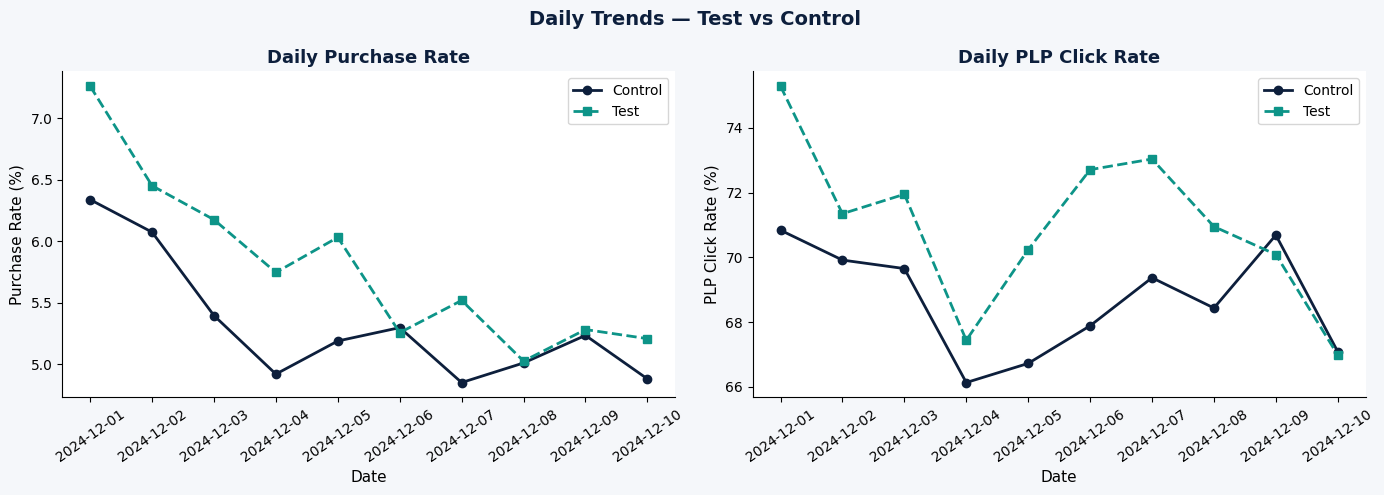

Saved: ab_daily_trends.png


In [14]:
daily = (
    df.groupby(['dt', 'variant'])
    .agg(
        users     = ('user_identifier', 'nunique'),
        purchases = ('purchase', 'sum'),
        clicks    = ('plp_click', 'sum'),
    )
    .reset_index()
)
daily['purchase_rate'] = daily['purchases'] / daily['users']
daily['click_rate']    = daily['clicks']    / daily['users']

ctrl_daily = daily[daily['variant'] == 'control'].sort_values('dt')
test_daily = daily[daily['variant'] == 'test'].sort_values('dt')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Daily Trends — Test vs Control', fontsize=14,
             fontweight='bold', color=NAVY)

for ax, metric, ylabel, title in [
    (axes[0], 'purchase_rate', 'Purchase Rate', 'Daily Purchase Rate'),
    (axes[1], 'click_rate',    'PLP Click Rate', 'Daily PLP Click Rate'),
]:
    ax.plot(ctrl_daily['dt'], ctrl_daily[metric] * 100,
            color=NAVY, marker='o', linewidth=2, label='Control', markersize=6)
    ax.plot(test_daily['dt'], test_daily[metric] * 100,
            color=GREEN, marker='s', linewidth=2, label='Test', markersize=6,
            linestyle='--')
    ax.set_xlabel('Date')
    ax.set_ylabel(f'{ylabel} (%)')
    ax.set_title(title, fontweight='bold', color=NAVY)
    ax.legend()
    ax.tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.savefig('ab_daily_trends.png', dpi=150, bbox_inches='tight',
            facecolor='#F5F7FA')
plt.show()
print('Saved: ab_daily_trends.png')

---
## 10. Logged-In Only Analysis
The carousel is personalised only for logged-in users. The overall results include logged-out users who see a generic carousel in both variants. Filtering to logged-in users gives the true signal.

In [15]:
logged_in_df = user_df[user_df['is_logged_in'] == 'logged in']

grp_li = logged_in_df.groupby('variant').agg(
    n_users    = ('user_identifier', 'count'),
    purchasers = ('did_purchase',    'sum'),
    clickers   = ('did_click',       'sum'),
).reset_index()

ctrl_li = grp_li[grp_li['variant'] == 'control'].iloc[0]
test_li = grp_li[grp_li['variant'] == 'test'].iloc[0]

print('='*55)
print(' LOGGED-IN USERS ONLY')
print(f' (n={len(logged_in_df):,} users)')
print('='*55)

purchase_li = z_test_proportions(
    ctrl_li['n_users'], test_li['n_users'],
    ctrl_li['purchasers'], test_li['purchasers'],
    metric_name='Purchase Rate (Logged-in)'
)

click_li = z_test_proportions(
    ctrl_li['n_users'], test_li['n_users'],
    ctrl_li['clickers'], test_li['clickers'],
    metric_name='PLP Click Rate (Logged-in)'
)

 LOGGED-IN USERS ONLY
 (n=87,755 users)

── Purchase Rate (Logged-in) ──
  Control:      10.8365%  (3,836 / 35,399)
  Test:         10.6979%  (5,601 / 52,356)
  Relative lift: -1.28%
  Absolute lift: -0.1386%
  95% CI:       [-0.5568%, 0.2797%]
  z-stat:       -0.6499
  p-value:      0.515731
  Result:       ❌ NOT SIGNIFICANT (alpha=0.05)

── PLP Click Rate (Logged-in) ──
  Control:      47.2923%  (16,741 / 35,399)
  Test:         47.0261%  (24,621 / 52,356)
  Relative lift: -0.56%
  Absolute lift: -0.2662%
  95% CI:       [-0.9394%, 0.4071%]
  z-stat:       -0.7749
  p-value:      0.438402
  Result:       ❌ NOT SIGNIFICANT (alpha=0.05)


---
## 11. Final Summary & Business Recommendation

In [16]:
print('='*60)
print(' FINAL RESULTS SUMMARY')
print('='*60)
print(f'  Test period:        {df["dt"].min()} to {df["dt"].max()} (10 days)')
print(f'  Total users:        {n_total:,}')
print(f'  Control users:      {n_control:,}')
print(f'  Test users:         {n_test:,}')
print()

all_results = [purchase_result, click_result, view_result]
for r in all_results:
    sig = '✅ SIGNIFICANT' if r['significant'] else '❌ NOT SIGNIFICANT'
    print(f"  {r['metric']:<20} {r['rate_control']:.3%} → {r['rate_test']:.3%}  "
          f"({r['relative_lift']:+.2f}%)  {sig}")

print()
print('─'*60)

# Decision logic
if purchase_result['significant'] and purchase_result['relative_lift'] > 0:
    decision = 'SHIP THE TEST ALGORITHM'
    rationale = 'Purchase rate shows statistically significant positive lift.'
elif not purchase_result['significant']:
    decision = 'DO NOT SHIP YET — EXTEND THE TEST'
    rationale = 'Purchase rate lift is not statistically significant. Need more data or longer runtime.'
else:
    decision = 'DO NOT SHIP — TEST IS WORSE'
    rationale = 'Test algorithm shows negative impact on purchase rate.'

print(f'\n  RECOMMENDATION: {decision}')
print(f'  Rationale: {rationale}')

# SRM caveat
if srm_p < 0.01:
    print(f'\n  ⚠️  CAVEAT: SRM detected (p={srm_p:.4f}). Results should be')
    print(f'     validated after investigating the randomisation issue.')

print('='*60)

 FINAL RESULTS SUMMARY
  Test period:        2024-12-01 to 2024-12-10 (10 days)
  Total users:        165,694
  Control users:      82,106
  Test users:         83,588

  Purchase Rate        7.319% → 8.482%  (+15.90%)  ✅ SIGNIFICANT
  PLP Click Rate       38.643% → 41.240%  (+6.72%)  ✅ SIGNIFICANT
  PLP View Rate        98.788% → 98.856%  (+0.07%)  ❌ NOT SIGNIFICANT

────────────────────────────────────────────────────────────

  RECOMMENDATION: SHIP THE TEST ALGORITHM
  Rationale: Purchase rate shows statistically significant positive lift.

  ⚠️  CAVEAT: SRM detected (p=0.0003). Results should be
     validated after investigating the randomisation issue.
